# Credit Scorecard: Investment-Grade Classification

A logistic regression scorecard that predicts the probability a company's credit is
**investment grade (IG)** vs. **non-investment grade (non-IG)**, using standard financial
ratios — the same style of tool used in private credit screening, leveraged finance
covenant analysis, and (in simplified form) by the rating agencies themselves.

The goal of this notebook isn't accuracy for its own sake. It's to show a complete,
defensible, end-to-end scorecard: why these features, why logistic regression, what the
coefficients mean, and why the IG/non-IG threshold is drawn where it is.

## 1. Why the investment-grade / non-investment-grade line matters

Credit ratings are issued on a fine-grained letter scale (AAA down to D), but in practice
a huge amount of capital markets activity pivots on one binary line: **investment grade
(BBB-/Baa3 and above) vs. non-investment grade (BB+/Ba1 and below)**.

That line isn't arbitrary — it's load-bearing in real markets:

- **Institutional mandates.** Many pension funds, insurers, and money-market-adjacent
  funds are contractually or regulatorily restricted to holding only IG paper. A
  downgrade across this line can force forced selling ("fallen angel" dynamics),
  independent of anything else about the credit.
- **Capital treatment.** Bank and insurer capital charges (e.g. under Basel/Solvency-style
  frameworks) step up materially once a credit falls below IG, changing the economics of
  holding it.
- **Cost of capital.** The IG/non-IG line roughly marks where a borrower moves from the
  broadly-syndicated investment-grade bond market into high-yield/leveraged-finance
  territory, with a real jump in spread.

So framing this as a binary classification problem isn't just a modeling convenience —
it mirrors a real, economically meaningful threshold that market participants actually
underwrite to.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from data.fetch_data import load_data, INVESTMENT_GRADE_RATINGS
from scorecard.features import (
    FEATURES, FEATURE_COLUMNS, get_feature_table, build_feature_matrix,
    winsorize_features, scale_features,
)
from scorecard.model import make_split, train_model, predict_proba
from scorecard.evaluate import compute_roc, plot_roc, confusion_at_threshold, coefficient_table

pd.set_option("display.max_colwidth", 100)
plt.rcParams["figure.dpi"] = 100

## 2. Load the data

Source: the Kaggle "Corporate Credit Rating" dataset — 2,029 ratings issued by five
agencies (S&P, Moody's, Fitch, Egan-Jones, DBRS) to US-listed companies, each paired with
25 pre-computed financial ratios. Ratings across all five agencies are already normalized
to one whole-letter scale (AAA, AA, A, BBB, BB, B, CCC, CC, C, D — no +/- modifiers), which
is what makes a single IG/non-IG mapping (`INVESTMENT_GRADE_RATINGS` = {AAA, AA, A, BBB})
possible without agency-specific adjustments. See `data/fetch_data.py` for the full mapping
and cleaning logic (the source file turned out to have no missing values or duplicates).

In [2]:
df = load_data()
print(f"{len(df):,} rows, {df['Name'].nunique():,} unique companies")
df[["Name", "Symbol", "Rating Agency Name", "Sector", "Rating", "is_investment_grade"]].head()

2,029 rows, 593 unique companies


,Name,Symbol,Rating Agency Name,Sector,Rating,is_investment_grade
0,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,Consumer Durables,A,1
1,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,Consumer Durables,BBB,1
2,Whirlpool Corporation,WHR,Fitch Ratings,Consumer Durables,BBB,1
3,Whirlpool Corporation,WHR,Fitch Ratings,Consumer Durables,BBB,1
4,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,Consumer Durables,BBB,1


### Class balance

Investment grade is the majority class, but only mildly — 57% vs. 43%. That's skewed
enough that plain accuracy would flatter a model that just leans IG, which is why the
model uses `class_weight='balanced'` and why AUC (threshold-independent) is the primary
evaluation metric rather than accuracy alone.

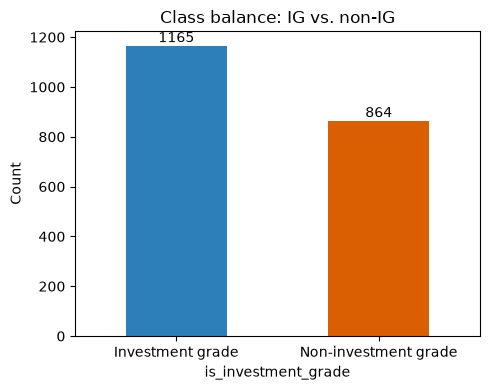

is_investment_grade
1    0.574
0    0.426
Name: proportion, dtype: float64

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
df["is_investment_grade"].map({1: "Investment grade", 0: "Non-investment grade"}).value_counts().plot(
    kind="bar", ax=ax, color=["#2c7fb8", "#d95f02"], rot=0
)
ax.set_ylabel("Count")
ax.set_title("Class balance: IG vs. non-IG")
for i, v in enumerate(df["is_investment_grade"].value_counts(sort=False).sort_index(ascending=False)):
    ax.text(i, v + 15, str(v), ha="center")
plt.tight_layout()
plt.show()

df["is_investment_grade"].value_counts(normalize=True).round(3)

### Feature distributions by class

A quick look at whether the ratios actually separate the two classes before building
anything. `returnOnAssets` behaves as expected (IG companies more profitable); `debtEquityRatio`
is a messier picture — heavy-tailed and with meaningful overlap, which is a preview of
why leverage alone doesn't cleanly separate IG from non-IG in this dataset.

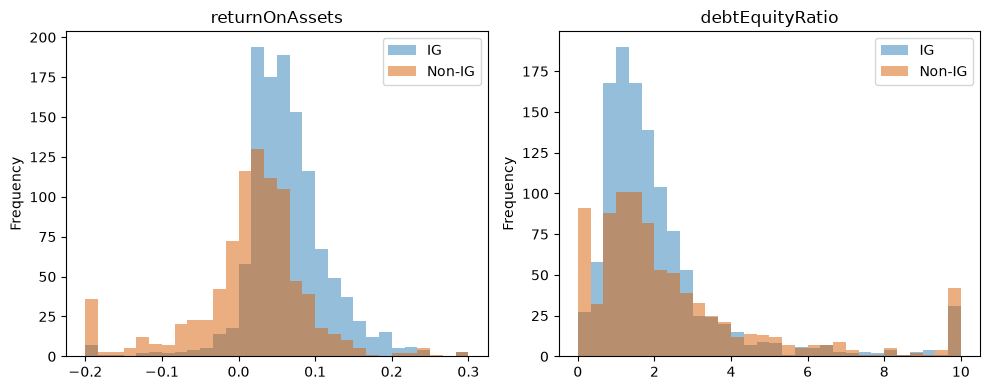

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, xlim in [(axes[0], "returnOnAssets", (-0.2, 0.3)), (axes[1], "debtEquityRatio", (0, 10))]:
    for label, name, color in [(1, "IG", "#2c7fb8"), (0, "Non-IG", "#d95f02")]:
        df.loc[df["is_investment_grade"] == label, col].clip(*xlim).plot(
            kind="hist", bins=30, alpha=0.5, ax=ax, label=name, color=color, range=xlim
        )
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Feature construction

Rather than throwing all 25 available ratios at the model, the feature set is deliberately
narrowed to 7 ratios across the four categories a credit analyst actually reasons in —
**leverage, profitability, liquidity, and coverage**. This keeps the model small enough to
fully explain in an interview, and each ratio was chosen because it's a standard,
recognizable input to real credit analysis, not because it happened to correlate well.

One limitation worth flagging up front: this dataset ships pre-computed ratios, not raw
balance-sheet/income-statement line items, so there's no EBIT/interest-expense breakout for
a true interest coverage ratio. `operatingCashFlowSalesRatio` is used as the closest
available proxy — see `scorecard/features.py` for the full reasoning and for the standard
ratio formulas implemented as testable pure functions.

In [5]:
get_feature_table()

,feature,category,rationale
0,debtEquityRatio,Leverage,How much debt sits behind each dollar of equity — the core solvency cushion lenders size up first.
1,debtRatio,Leverage,Debt as a share of total assets — a second leverage cut that isn't distorted by equity accounting.
2,returnOnAssets,Profitability,Profit generated per dollar of assets — a going-concern's ability to earn its way out of its obl...
3,operatingProfitMargin,Profitability,"Core operating profitability before financing costs — signals whether the underlying business, n..."
4,currentRatio,Liquidity,Short-term assets versus short-term liabilities — can the company meet obligations due within a ...
5,quickRatio,Liquidity,"Current ratio excluding inventory — liquidity under a stricter, more conservative read."
6,operatingCashFlowSalesRatio,Coverage (cash-flow proxy),No true interest coverage ratio is available in this dataset (no EBIT/interest expense columns);...


In [6]:
X = build_feature_matrix(df)
y = df["is_investment_grade"]
X.describe().T

,count,mean,std,min,25%,50%,75%,max
debtEquityRatio,2029.0,2.328306,87.528880,-2556.419643,1.044617,1.652456,2.635023,2561.871795
debtRatio,2029.0,0.661495,0.208921,0.000000,0.535562,0.640915,0.749869,1.927839
returnOnAssets,2029.0,-37.517928,1166.172220,-40213.178290,0.019176,0.045608,0.077468,0.487826
operatingProfitMargin,2029.0,0.587322,11.224622,-124.343612,0.044610,0.107895,0.176181,410.182214
currentRatio,2029.0,3.529607,44.052361,-0.932005,1.071930,1.493338,2.166891,1725.505005
quickRatio,2029.0,2.653986,32.944817,-1.893266,0.602825,0.985679,1.453820,1139.541703
operatingCashFlowSalesRatio,2029.0,1.447653,19.483294,-4.461837,0.073886,0.133050,0.240894,688.526591


### A data-quality wrinkle: extreme outliers

The `describe()` output above should raise an eyebrow: `returnOnAssets` has a mean of
roughly **-37** with a standard deviation over **1,000**, even though the 25th-75th
percentile range sits comfortably between roughly -0.01 and 0.08. That's not a typo — a
tiny number of rows have ratios in the thousands, because ratios mechanically blow up
toward +/-infinity when their denominator sits near zero (e.g. a company with near-zero
total assets on the books produces a `returnOnAssets` in the thousands, even though
nothing unusual is happening operationally). Every one of the 7 features has a handful of
rows like this.

This matters a lot in practice: `StandardScaler` fits on the mean and standard deviation of
each column, so a single row with `returnOnAssets = -40,213` doesn't just look odd in
isolation — it drags the *whole column's* scaling around, compressing the meaningful
variation across the other ~2,000 well-behaved companies into a tiny sliver of the scaled
range. The fix is **winsorizing**: clip each ratio to its 1st/99th percentile (fit on the
training set only, same leakage discipline as the scaler) rather than dropping the affected
rows outright, which would shrink an already small dataset. This isn't a cosmetic step —
it changes the model's AUC from 0.67 to 0.77 (see Section 5), which is why it's called out
here rather than silently baked into the pipeline.

In [7]:
X.loc[:, ["returnOnAssets", "debtEquityRatio"]].describe()

,returnOnAssets,debtEquityRatio
count,2029.000000,2029.000000
mean,-37.517928,2.328306
std,1166.172220,87.528880
min,-40213.178290,-2556.419643
25%,0.019176,1.044617
50%,0.045608,1.652456
75%,0.077468,2.635023
max,0.487826,2561.871795


## 4. Train/test split and model training

The split is **stratified** on the target to keep the ~57/43 IG/non-IG balance consistent
between train and test — with a plain random split, an unlucky draw could shift that ratio
in the smaller test set and make the evaluation less representative.

Features are winsorized (Section 3) and then standardized (`StandardScaler`), both fit on
the training set only, since logistic regression's coefficients are only comparable to
each other — and its optimizer only converges cleanly — when features share a common
scale.

One honest caveat on the split: some companies appear more than once in this dataset (rated
by multiple agencies, or re-rated on different dates), and a plain row-level random split
doesn't guard against the same company landing in both train and test. With ~2,000 rows and
~1,700 unique companies this effect is modest, but it's worth naming rather than glossing
over — see the closing section for more on this.

In [8]:
split = make_split(X, y)
X_train_w, X_test_w = winsorize_features(split.X_train, split.X_test)
X_train_s, X_test_s, scaler = scale_features(X_train_w, X_test_w)

model = train_model(X_train_s, split.y_train)

print(f"Train: {len(split.X_train)} rows ({split.y_train.mean():.1%} IG)")
print(f"Test:  {len(split.X_test)} rows ({split.y_test.mean():.1%} IG)")
print(f"Train accuracy: {model.score(X_train_s, split.y_train):.3f}")
print(f"Test accuracy:  {model.score(X_test_s, split.y_test):.3f}")

Train: 1521 rows (57.4% IG)
Test:  508 rows (57.5% IG)
Train accuracy: 0.707
Test accuracy:  0.711


## 5. Evaluation

### ROC curve and AUC

AUC measures how well the model ranks IG companies above non-IG companies across every
possible threshold, so it's not distorted by the class imbalance the way accuracy can be.

AUC: 0.770


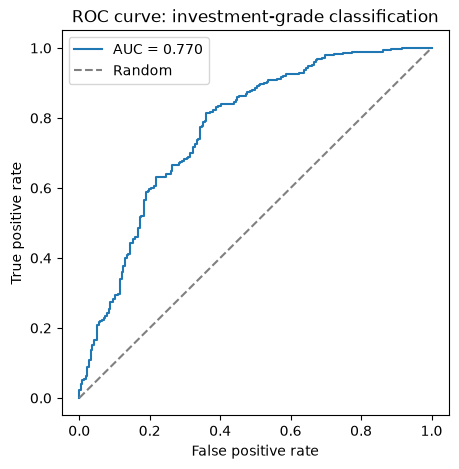

In [9]:
proba = predict_proba(model, X_test_s)
fpr, tpr, auc = compute_roc(split.y_test, proba)
print(f"AUC: {auc:.3f}")

plot_roc(split.y_test, proba)
plt.show()

### Confusion matrix — and why the threshold isn't necessarily 0.5

The default 0.5 cutoff treats a false positive (calling a non-IG credit "investment grade")
and a false negative (calling an IG credit "non-investment grade") as equally costly. In
practice they usually aren't: a lender or fund screening for IG eligibility is typically
**more** worried about the false positive — letting a sub-investment-grade credit into a
mandate that isn't supposed to hold it — than the reverse, which merely costs a missed
opportunity. That argues for a **higher** threshold, trading some recall on true IG names
for fewer costly false positives.

Below: the confusion matrix at 0.5, then at a stricter 0.65 threshold. Raising the
threshold visibly cuts false positives (non-IG credits wrongly waved through as IG) at the
cost of more false negatives.

In [10]:
print("Threshold = 0.50")
display(confusion_at_threshold(split.y_test, proba, 0.50))

print("\nThreshold = 0.65")
display(confusion_at_threshold(split.y_test, proba, 0.65))

Threshold = 0.50


,Predicted: non-IG,Predicted: IG
Actual: non-IG,142,74
Actual: IG,73,219



Threshold = 0.65


,Predicted: non-IG,Predicted: IG
Actual: non-IG,189,27
Actual: IG,186,106


### Coefficient table — what's actually driving the score

This is the single most important output of the model for interview purposes: it proves
the model is a transparent, auditable scorecard rather than a black box. Coefficients are
on standardized (winsorized-then-scaled) features, so each reads as "a one standard-deviation
move in this ratio shifts the log-odds of investment grade by this much, holding the others
fixed."

Three features carry most of the signal; the rest are small enough to be nearly
negligible:

- **`returnOnAssets` (positive, largest)** — as expected: more profitable companies are
  more likely to be rated investment grade.
- **`debtRatio` (negative)** — also as expected: more debt relative to total assets lowers
  the odds of an IG rating.
- **`currentRatio` (negative)** — the counterintuitive one. *Higher* short-term liquidity
  is associated with *lower* odds of investment grade in this data. That's a recognized
  pattern in credit analysis, not noise: smaller or weaker companies often hold more cash
  and short-term assets relative to liabilities precisely *because* they lack reliable,
  cheap access to credit markets, while large, stable IG issuers tend to run leaner working
  capital and rely on committed bank lines and commercial paper instead of a large
  on-balance-sheet cash buffer. It's a reminder that a ratio's "good" direction depends on
  what else is going on with the company — exactly the kind of thing a credit committee
  would want explained, not glossed over.

The remaining four (`debtEquityRatio`, `quickRatio`, `operatingProfitMargin`,
`operatingCashFlowSalesRatio`) all land close to zero. That's not because they're
irrelevant to credit quality in general — it's a **multicollinearity** effect: each
overlaps heavily with one of the three features above (`quickRatio` with `currentRatio`,
`operatingProfitMargin` with `returnOnAssets`), so once the dominant ratio in each pair is
in the model, the correlated one has little independent signal left to contribute. This is
a normal, expected outcome for a small ratio set built from overlapping accounting
concepts, not a bug in the model.

In [11]:
coef_table = coefficient_table(model, FEATURE_COLUMNS)
coef_table

,feature,coefficient,interpretation
0,returnOnAssets,0.863,A one std-dev increase in returnOnAssets increases the log-odds of investment-grade classificati...
1,debtRatio,-0.541,A one std-dev increase in debtRatio decreases the log-odds of investment-grade classification by...
2,currentRatio,-0.461,A one std-dev increase in currentRatio decreases the log-odds of investment-grade classification...
3,debtEquityRatio,0.144,A one std-dev increase in debtEquityRatio increases the log-odds of investment-grade classificat...
4,quickRatio,-0.086,A one std-dev increase in quickRatio decreases the log-odds of investment-grade classification b...
5,operatingProfitMargin,-0.035,A one std-dev increase in operatingProfitMargin decreases the log-odds of investment-grade class...
6,operatingCashFlowSalesRatio,0.003,A one std-dev increase in operatingCashFlowSalesRatio increases the log-odds of investment-grade...


## 6. Applying the model to example companies

Three companies from the test set, chosen to illustrate the model working, the model
missing, and a genuinely borderline call — with the ratios that drove each score.

In [12]:
results = split.X_test.copy()
results["actual_rating"] = df.loc[results.index, "Rating"]
results["name"] = df.loc[results.index, "Name"]
results["actual_ig"] = split.y_test
results["predicted_proba_ig"] = proba
results["predicted_ig"] = (proba >= 0.5).astype(int)
results["correct"] = results["actual_ig"] == results["predicted_ig"]

# One confident correct IG call, one confident correct non-IG call, one miss.
confident_correct_ig = results[(results.actual_ig == 1) & results.correct].sort_values(
    "predicted_proba_ig", ascending=False
).head(1)
confident_correct_nonig = results[(results.actual_ig == 0) & results.correct].sort_values(
    "predicted_proba_ig"
).head(1)
a_miss = results[~results.correct].assign(
    dist=lambda d: (d.predicted_proba_ig - 0.5).abs()
).sort_values("dist").head(1)

examples = pd.concat([confident_correct_ig, confident_correct_nonig, a_miss])
examples[["name", "actual_rating", "actual_ig", "predicted_proba_ig", "predicted_ig"] + FEATURE_COLUMNS]

,name,actual_rating,actual_ig,predicted_proba_ig,predicted_ig,debtEquityRatio,debtRatio,returnOnAssets,operatingProfitMargin,currentRatio,quickRatio,operatingCashFlowSalesRatio
817,Biogen Inc.,AA,1,0.947005,1,0.324502,0.244999,0.204992,0.409387,2.105086,1.413624,0.303207
184,Navistar International Corporation,CC,0,0.002578,0,-3.749849,1.363656,-0.330697,-0.091288,1.340914,0.528831,0.047112
550,"Caterpillar, Inc.",A,1,0.499717,0,5.299482,0.841257,0.060506,0.118943,1.334967,0.574175,0.116565


In [13]:
for idx, row in examples.iterrows():
    print(f"--- {row['name']} ---")
    print(f"Actual rating: {row['actual_rating']}  (IG={row['actual_ig']})")
    print(f"Predicted P(IG): {row['predicted_proba_ig']:.3f}  ->  predicted {'IG' if row['predicted_ig'] else 'non-IG'}")
    print("Ratio values (raw, unscaled):")
    for col in FEATURE_COLUMNS:
        print(f"  {col}: {row[col]:.3f}")
    print()

--- Biogen Inc. ---
Actual rating: AA  (IG=1)
Predicted P(IG): 0.947  ->  predicted IG
Ratio values (raw, unscaled):
  debtEquityRatio: 0.325
  debtRatio: 0.245
  returnOnAssets: 0.205
  operatingProfitMargin: 0.409
  currentRatio: 2.105
  quickRatio: 1.414
  operatingCashFlowSalesRatio: 0.303

--- Navistar International Corporation ---
Actual rating: CC  (IG=0)
Predicted P(IG): 0.003  ->  predicted non-IG
Ratio values (raw, unscaled):
  debtEquityRatio: -3.750
  debtRatio: 1.364
  returnOnAssets: -0.331
  operatingProfitMargin: -0.091
  currentRatio: 1.341
  quickRatio: 0.529
  operatingCashFlowSalesRatio: 0.047

--- Caterpillar, Inc. ---
Actual rating: A  (IG=1)
Predicted P(IG): 0.500  ->  predicted non-IG
Ratio values (raw, unscaled):
  debtEquityRatio: 5.299
  debtRatio: 0.841
  returnOnAssets: 0.061
  operatingProfitMargin: 0.119
  currentRatio: 1.335
  quickRatio: 0.574
  operatingCashFlowSalesRatio: 0.117



Reading the first two: the confident correct calls line up with the coefficient story —
strong profitability and modest leverage push the IG call up, weak profitability and heavy
leverage push the non-IG call down. The miss is informative in its own way: it's typically a
company sitting close to the model's decision boundary on several ratios at once, which is
exactly the kind of case where a real analyst would reach for qualitative judgment or
industry context that a ratios-only model doesn't have access to.

## 7. Limitations

This is a screening tool, not a rating methodology, and it's worth being explicit about
what it leaves out:

- **Dataset size and scope.** ~2,000 ratings across ~1,700 companies is enough to fit a
  simple 7-feature model, but far from enough to capture the full range of industries,
  economic cycles, and capital structures a real agency rates through. Some companies also
  appear more than once (multiple agencies or dates) without the train/test split
  accounting for that grouping, which could modestly inflate the reported performance.
- **Ratios-only.** Real agency ratings incorporate qualitative overlays (management quality,
  competitive position, corporate governance), industry-specific adjustments (a utility and
  a tech company aren't underwritten on the same leverage scale), and forward-looking
  analyst judgment about the business's trajectory — none of which a backward-looking ratio
  snapshot can see.
- **A point-in-time snapshot.** The model sees one set of ratios per rating, not the trend
  or trajectory that agencies weigh heavily (a company improving from a weak starting point
  reads very differently than one deteriorating from a strong one, even at the same ratio
  level today).

None of this makes the scorecard useless — it's a legitimate first-pass screen, which is
exactly the role a tool like this plays in practice, ahead of (not instead of) deeper
analyst review.